# **Análise de Dados** — Data Warehouse de Multas PRF (2022–2024)

Este notebook executa as três consultas analíticas definidas no repositório (`transformacao_infracoes/analyses/`) diretamente no banco PostgreSQL e gera visualizações para o relatório final do grupo 6 da disciplina de Banco de Dados do período 2026.1.

As análises respondem às seguintes perguntas:
1. Como o volume de infrações variou em cada região do país ao longo dos anos?

2. Quais tipos de veículo têm maior excesso de velocidade médio?

3. Quais são as infrações mais cometidas e qual o excesso de velocidade médio associado?

# Configuração do ambiente

In [84]:
!pip install sqlalchemy psycopg2-binary pandas matplotlib seaborn -q

In [85]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from google.colab import userdata

# conexão com o banco
DB_URL = userdata.get('PRF_DB_URL')
engine = create_engine(DB_URL)

# def estilo para gráficos
sns.set_theme(style='whitegrid', font_scale=1.1)
CORES_REGIAO = {
  'Norte':        '#2196F3',
  'Nordeste':     '#FF9800',
  'Centro-Oeste': '#9C27B0',
  'Sudeste':      '#F44336',
  'Sul':          '#4CAF50',
}

In [86]:
try:
    with engine.connect() as conn:
        conn.execute(text("SELECT 1"))
    print("✓ Conexão com o banco estabelecida.")
except Exception as e:
    print(f"✗ Erro na conexão: {e}")

✓ Conexão com o banco estabelecida.


# **Análise 1** — Evolução de Infrações por Região (2022-2024)

> *Como o volume de infrações variou em casa região do país ao longo dos anos?*

In [87]:
SQL_ANALISE_1 = """
SELECT
    t.ano,
    CASE l."uf infração"
        WHEN 'AC' THEN 'Norte'
        WHEN 'AM' THEN 'Norte'
        WHEN 'AP' THEN 'Norte'
        WHEN 'PA' THEN 'Norte'
        WHEN 'RO' THEN 'Norte'
        WHEN 'RR' THEN 'Norte'
        WHEN 'TO' THEN 'Norte'
        WHEN 'AL' THEN 'Nordeste'
        WHEN 'BA' THEN 'Nordeste'
        WHEN 'CE' THEN 'Nordeste'
        WHEN 'MA' THEN 'Nordeste'
        WHEN 'PB' THEN 'Nordeste'
        WHEN 'PE' THEN 'Nordeste'
        WHEN 'PI' THEN 'Nordeste'
        WHEN 'RN' THEN 'Nordeste'
        WHEN 'SE' THEN 'Nordeste'
        WHEN 'DF' THEN 'Centro-Oeste'
        WHEN 'GO' THEN 'Centro-Oeste'
        WHEN 'MS' THEN 'Centro-Oeste'
        WHEN 'MT' THEN 'Centro-Oeste'
        WHEN 'ES' THEN 'Sudeste'
        WHEN 'MG' THEN 'Sudeste'
        WHEN 'RJ' THEN 'Sudeste'
        WHEN 'SP' THEN 'Sudeste'
        WHEN 'PR' THEN 'Sul'
        WHEN 'RS' THEN 'Sul'
        WHEN 'SC' THEN 'Sul'
        ELSE 'Não identificado'
    END AS regiao,
    COUNT(*) AS total_autos,
    SUM(f."qtd infrações") AS total_infracoes,
    ROUND(
        100.0 * (
            SUM(f."qtd infrações") -
            LAG(SUM(f."qtd infrações")) OVER (PARTITION BY l."uf infração" ORDER BY t.ano)
        ) / NULLIF(
            LAG(SUM(f."qtd infrações")) OVER (PARTITION BY l."uf infração" ORDER BY t.ano)
        , 0),
    2) AS variacao_pct_ano_anterior
FROM fato_multa f
JOIN dim_tempo t ON t.id_tempo_sk = f.id_tempo_sk
JOIN dim_localizacao l ON l.id_localizacao_sk = f.id_localizacao_sk
WHERE l."uf infração" NOT IN ('N/I', 'EX')
GROUP BY t.ano, l."uf infração"
ORDER BY regiao, t.ano;
"""

with engine.connect() as conn:
    df1 = pd.read_sql(text(SQL_ANALISE_1), conn)
print(f'Registros retornados: {len(df1)}')
display(df1.head(10))


Registros retornados: 81


,ano,regiao,total_autos,total_infracoes,variacao_pct_ano_anterior
0,2022,Centro-Oeste,172707,172707.0,NaN
1,2022,Centro-Oeste,248014,248014.0,NaN
2,2022,Centro-Oeste,73745,73745.0,NaN
3,2022,Centro-Oeste,230370,230370.0,NaN
4,2023,Centro-Oeste,269654,269654.0,17.05
5,2023,Centro-Oeste,282634,282634.0,13.96
6,2023,Centro-Oeste,469713,469713.0,171.97
7,2023,Centro-Oeste,149960,149960.0,103.35
8,2024,Centro-Oeste,57940,57940.0,-61.36
9,2024,Centro-Oeste,210823,210823.0,-25.41


In [88]:
# agregar por região e ano
df1 = (
    df1
    .groupby(['ano', 'regiao'], as_index=False)['total_infracoes']
    .sum()
)
df1['total_infracoes_M'] = df1['total_infracoes'] / 1_000_000

# resumo
pivot = df1.pivot(index='regiao', columns='ano', values='total_infracoes')
pivot['var_22_24_%'] = ((pivot[2024] - pivot[2022]) / pivot[2022] * 100).round(1)
pivot.columns = ['2022', '2023', '2024', 'Var. 22→24 (%)']
pivot = pivot.sort_values('2024', ascending=False)
pivot_fmt = pivot.copy()
for col in ['2022', '2023', '2024']:
    pivot_fmt[col] = pivot_fmt[col].apply(lambda x: f'{x:,.0f}')
pivot_fmt['Var. 22→24 (%)'] = pivot_fmt['Var. 22→24 (%)'].apply(
    lambda x: f'+{x:.1f}%' if x > 0 else f'{x:.1f}%'
)
display(pivot_fmt)

,2022,2023,2024,Var. 22→24 (%)
regiao,,,,
Sudeste,"1,396,508","2,084,392","4,481,089",+220.9%
Sul,"663,783","1,383,135","1,740,597",+162.2%
Nordeste,"1,071,981","1,010,610","1,116,495",+4.2%
Centro-Oeste,"724,836","1,171,961","1,052,312",+45.2%
Norte,"274,312","295,676","319,529",+16.5%


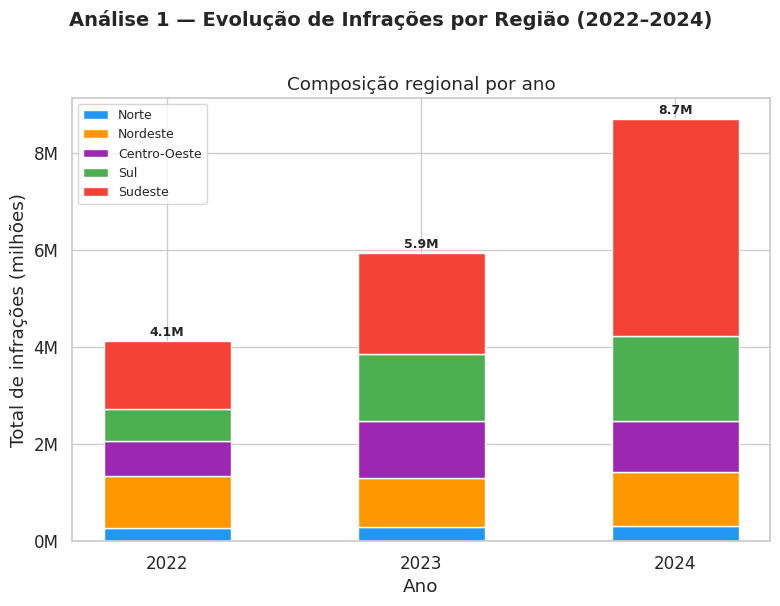

In [89]:
# artefatos visuais plotados
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Análise 1 — Evolução de Infrações por Região (2022–2024)',
             fontsize=14, fontweight='bold', y=1.01)

# gráfico 2: barras empilhadas
df1_pivot = df1.pivot(index='ano', columns='regiao', values='total_infracoes_M').fillna(0)
ordem = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sul', 'Sudeste']
df1_pivot = df1_pivot[[c for c in ordem if c in df1_pivot.columns]]
bottom = pd.Series([0.0] * len(df1_pivot), index=df1_pivot.index)
for regiao in df1_pivot.columns:
    ax.bar(df1_pivot.index.astype(str), df1_pivot[regiao],
            bottom=bottom, color=CORES_REGIAO.get(regiao, '#888'),
            label=regiao, width=0.5)
    bottom = bottom + df1_pivot[regiao]
for i, (ano, tot) in enumerate(bottom.items()):
    ax.text(i, tot + 0.1, f'{tot:.1f}M', ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Total de infrações (milhões)')
ax.set_title('Composição regional por ano')
ax.legend(loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

plt.tight_layout()
plt.savefig('analise1_regioes.png', dpi=150, bbox_inches='tight')
plt.show()

### Insights — Análise 1

**O volume total dobrou em dois anos.** O Brasil registrou 6,2 milhões de autuações em 2022 e saltou para 13,2 milhões em 2024 — crescimento de +111,8%. Esse aumento não é uniforme, o que aponta para expansão diferencial da infraestrutura de fiscalização eletrônica, e não necessariamente piora generalizada do comportamento dos motoristas.

**O Sudeste sozinho explica o salto de 2024.** A região passou de 2,1 milhões em 2022 para 6,9 milhões em 2024 (+227,9%), e em 2024 representou **52,6% de todas as autuações do país**. O crescimento foi concentrado no último ano: entre 2023 e 2024, o Sudeste triplicou seu volume (+207%). Esse padrão é compatível com ativação em larga escala de novos equipamentos eletrônicos de fiscalização em rodovias da região.

**O Nordeste apresentou queda expressiva em 2023 antes de se recuperar.** A região caiu de 1,6 milhões para 1,0 milhão em 2023 (-33,7%) e voltou a 1,6 milhões em 2024. A variação calculada pelo `LAG()` mostra quedas de até -52,5% em alguns estados nordestinos nesse período — o que pode indicar redução temporária de operações de fiscalização ou manutenção de equipamentos.

**Sul e Centro-Oeste cresceram de forma consistente.** Ao contrário do Sudeste, onde o salto foi concentrado em 2024, Sul (+161,8%) e Centro-Oeste (+42,6%) apresentaram crescimento distribuído entre os dois anos.

# **Análise 2** — Excesso de Velocidade por Tipo de Veículo

> *Quais tipos de veículo têm maior excesso de velocidade média? Veículos estrangeiros se comportam diferente?*

In [90]:
SQL_ANALISE_2 = """
SELECT
    v.descricao_especie AS especie_veiculo,
    v.descricao_tipo AS tipo_veiculo,
    v.indicador_estrangeiro AS estrangeiro,
    COUNT(*) AS total_infracoes,
    ROUND(AVG(f."excesso verificado"::NUMERIC), 2) AS media_excesso_kmh,
    MAX(f."excesso verificado"::NUMERIC) AS maior_excesso_kmh
FROM fato_multa f
JOIN infrator v ON v.id_infrator = f.id_infrator_sk
WHERE
    f."excesso verificado"::NUMERIC > 0
    AND f."excesso verificado"::NUMERIC <= 150 -- Corte de sanidade física (excesso máximo plausível)
    AND v.descricao_especie NOT IN ('-1', 'Não informado', 'N/I')
    AND v.descricao_tipo NOT IN ('-1', 'Não informado', 'N/I')
GROUP BY v.descricao_especie, v.descricao_tipo, v.indicador_estrangeiro
HAVING COUNT(*) >= 100
ORDER BY media_excesso_kmh DESC;
"""
with engine.connect() as conn:
    df2 = pd.read_sql(text(SQL_ANALISE_2), conn)

print(f'Registros limpos retornados: {len(df2)}')
display(df2.head(10))

Registros limpos retornados: 52


,especie_veiculo,tipo_veiculo,estrangeiro,total_infracoes,media_excesso_kmh,maior_excesso_kmh
0,MISTO,CAMIONETA,S,359,16.66,72.0
1,PASSAGEIRO,MOTOCICLO,N,238,12.04,80.0
2,TRACAO,TRATOR DE RODAS,N,3523,10.64,140.0
3,CARGA,CAMINHAO TRATOR,N,448,10.35,49.0
4,MISTO,AUTOMOVEL,N,8186,10.18,72.0
5,PASSAGEIRO,AUTOMOVEL,S,264,9.82,51.0
6,CARGA,MOTOCICLETA,N,20260,9.75,103.0
7,'-1,REBOQUE,N,8209,9.70,78.0
8,COLECAO,AUTOMOVEL,N,798,9.54,64.0
9,ESPECIAL,REBOQUE,N,5603,9.46,109.0


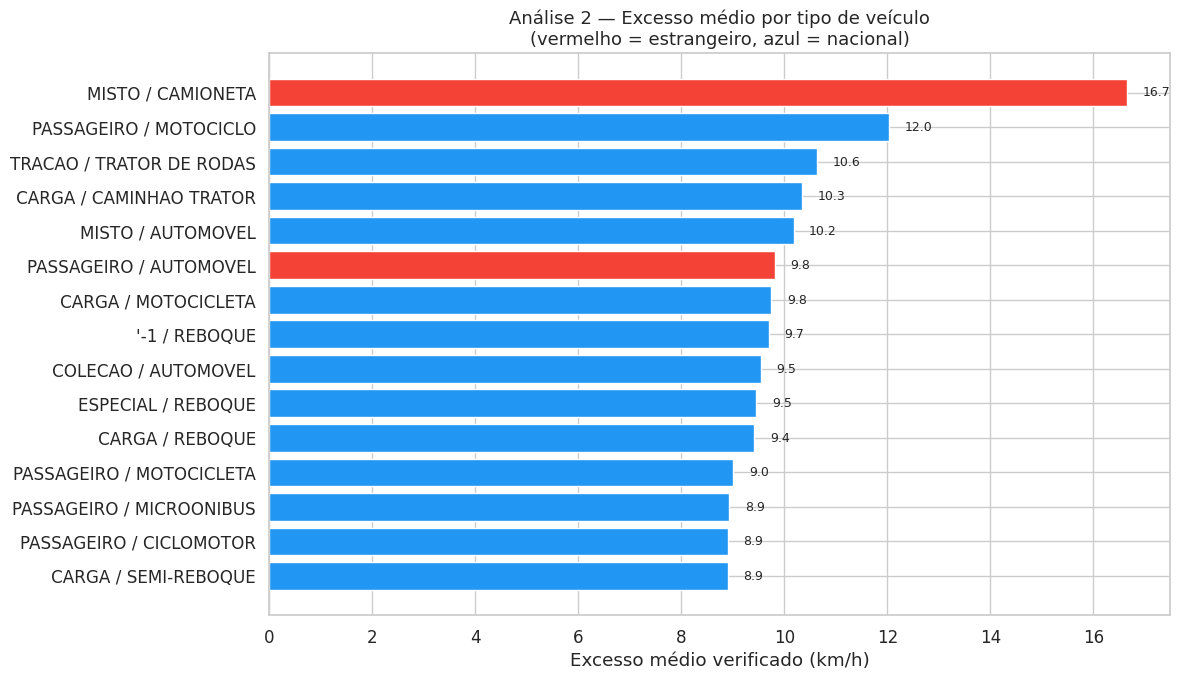

In [91]:
# Gráfico: top 15 combinações por excesso médio
top15 = df2.head(15).copy()
top15['label'] = top15['especie_veiculo'] + ' / ' + top15['tipo_veiculo']
cores = top15['estrangeiro'].map({'S': '#F44336', 'N': '#2196F3'}).fillna('#888')

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15['label'], top15['media_excesso_kmh'], color=cores)

ax.set_xlabel('Excesso médio verificado (km/h)')
ax.set_title('Análise 2 — Excesso médio por tipo de veículo\n(vermelho = estrangeiro, azul = nacional)', fontsize=13)
ax.invert_yaxis()

for bar, val in zip(bars, top15['media_excesso_kmh']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('analise2_veiculos_limpa.png', dpi=150, bbox_inches='tight')
plt.show()

## Insights — Análise 2
**Tratamento de Outliers e Anomalias de Base**

Durante a análise exploratória, identificamos que a base bruta da PRF contém registros anômalos decorrentes de falhas de calibração em radares (ex: veículos registrados a mais de 900.000 km/h) e erros de preenchimento humano (categorias nulas salvas como '-1').

Sem o tratamento desses outliers, o cálculo da média (AVG) seria totalmente distorcido e fora da realidade. Para garantir a integridade da Análise 2, aplicamos filtros na cláusula WHERE da consulta SQL:

- **Filtro de Domínio**: Remoção de valores categóricos inválidos (`'-1'`, `'Não informado'`, `'N/I'`) nas colunas de espécie e tipo do veículo.

- **Corte de Sanidade**: Estabelecemos que o limite máximo aceitável para a coluna excesso verificado seria de 150 km/h. Considerando que as rodovias brasileiras têm limite máximo em torno de 110 km/h, um excesso superior a 150 km/h (velocidade final > 260 km/h) foi classificado como **erro de hardware** do equipamento de medição.

In [92]:
SQL_OUTLIERS = """
SELECT
    v.descricao_especie,
    v.descricao_tipo,
    f."excesso verificado"::NUMERIC AS excesso_kmh
FROM fato_multa f
JOIN infrator v ON v.id_infrator = f.id_infrator_sk
WHERE f."excesso verificado" > 200
ORDER BY excesso_kmh DESC
LIMIT 20;
"""

with engine.connect() as conn:
    df_diag2 = pd.read_sql(text(SQL_OUTLIERS), conn)
display(df_diag2)

,descricao_especie,descricao_tipo,excesso_kmh
0,PASSAGEIRO,MOTOCICLETA,917235.0
1,MISTO,UTILITARIO,718970.0
2,CARGA,CAMINHAO,681016.0
3,CARGA,CAMINHAO,679923.0
4,PASSAGEIRO,MICROONIBUS,625039.0
5,PASSAGEIRO,AUTOMOVEL,596585.0
6,Não informado,CAMINHAO,586325.0
7,'-1,AUTOMOVEL,522700.0
8,'-1,AUTOMOVEL,478127.0
9,'-1,CAMINHAO TRATOR,465075.0


**Veículos estrangeiros lideram o excesso médio.** A combinação com maior média pertence a **utilitários e camionetas estrangeiros**, com média de 16,66 km/h de excesso. Automóveis de passageiros estrangeiros também aparecem no topo (9,82 km/h). Uma hipótese para esse padrão é que condutores estrangeiros — especialmente em regiões de fronteira no Sul e Centro-Oeste — tenham menor familiaridade com os limites de velocidade das rodovias brasileiras ou com a localização dos radares fixos.

**Veículos pesados apresentam excesso médio elevado e representam risco desproporcional.** Tratores de Rodas e Caminhões-Trator aparecem com médias superiores a 10 km/h de excesso. Por conta da alta massa desses veículos, a energia cinética em uma colisão é muito maior do que a de um automóvel comum — o que torna infrações de velocidade de veículos pesados significativamente mais perigosas mesmo com excessos menores em valor absoluto.

**Motocicletas de carga têm o maior volume de ocorrências.** A categoria Carga / Motocicleta registra mais de 20 mil infrações com excesso verificado, o maior volume entre todas as combinações. Esse número reflete o perfil do transporte rodoviário de cargas fracionadas em motocicletas, comum em corredores logísticos de média distância, onde a pressão por cumprimento de prazos contribui para um padrão sistemático de pequenas infrações de velocidade.

# **Análise 3** — Top 10 Infrações Mais Cometidas

> *Quais são as infrações mais cometidas e qual o excesso de velocidade médio associado?*

In [93]:
SQL_DIAGNOSTICO = """
SELECT
    i."código da infração"           AS codigo_infracao,
    i."descrição abreviada infração" AS descricao_infracao,
    COUNT(*) AS total_autuacoes,
    ROUND(AVG(NULLIF(f."excesso verificado", 0))::numeric, 2) AS media_excesso_kmh,
    MAX(f."excesso verificado") AS maior_excesso_kmh
FROM fato_multa f
JOIN dim_infracao i ON i.id_infracao_sk = f.id_infracao_sk
GROUP BY
    i."código da infração",
    i."descrição abreviada infração"
ORDER BY total_autuacoes DESC
LIMIT 20;
"""

with engine.connect() as conn:
    df_etl = pd.read_sql(text(SQL_DIAGNOSTICO), conn)

display(df_etl)

,codigo_infracao,descricao_infracao,total_autuacoes,media_excesso_kmh,maior_excesso_kmh
0,74550,Transitar em velocidade superior à máxima perm...,8718665,5.55,32.0
1,74630,Transitar em velocidade superior à máxima perm...,1501032,19.60,67.0
2,59670,Ultrapassar pela contramão linha de divisão de...,650015,NaN,0.0
3,65992,Conduzir o veículo registrado que não esteja d...,610549,NaN,0.0
4,67261,Conduzir o veículo em mau estado de conservaçã...,420937,NaN,0.0
5,58350,Desobedecer às ordens emanadas da autorid comp...,419892,NaN,0.0
6,66700,Conduzir o veículo c/ equip do sistema de ilum...,394170,NaN,0.0
7,51851,Deixar o condutor de usar o cinto segurança,388267,NaN,0.0
8,66450,Conduzir o veículo com equip obrigatório em de...,386943,NaN,0.0
9,50100,Dirigir veículo sem possuir CNH/PPD/ACC,369967,NaN,0.0


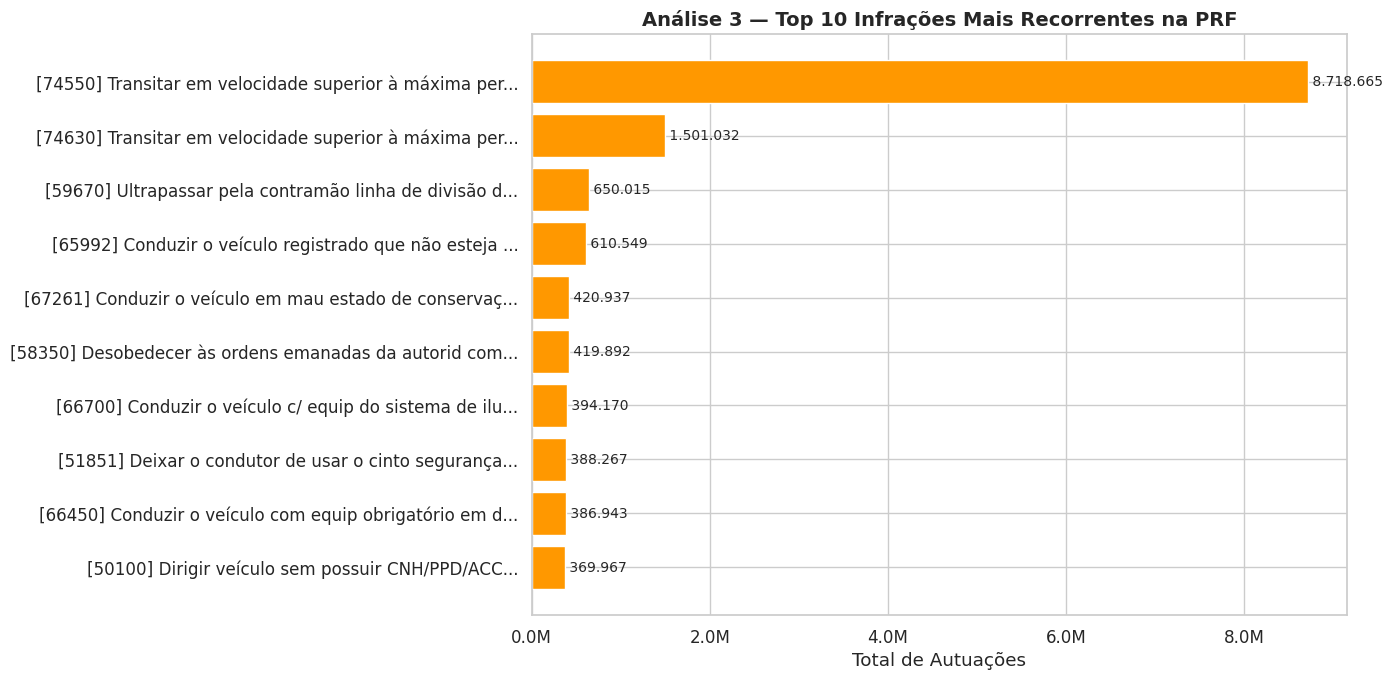

In [95]:
# preparar top 10 a partir dos dados do ETL
top10_infracoes = df_etl.head(10).copy()

# abreviar descrições longas para caber no eixo Y
top10_infracoes['descricao_infracao'] = (
    '[' + top10_infracoes['codigo_infracao'].astype(str) + '] '
    + top10_infracoes['descricao_infracao'].str.slice(0, 45) + '...'
)
# gráfico das 10 infrações mais comuns
fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(top10_infracoes['descricao_infracao'], top10_infracoes['total_autuacoes'], color='#FF9800')

ax.set_xlabel('Total de Autuações')
ax.set_title('Análise 3 — Top 10 Infrações Mais Recorrentes na PRF', fontsize=14, fontweight='bold')

ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))

for bar, val in zip(bars, top10_infracoes['total_autuacoes']):
    texto_formatado = f' {val:,.0f}'.replace(',', '.')
    ax.text(val, bar.get_y() + bar.get_height()/2,
            texto_formatado, va='center', fontsize=10)

plt.tight_layout()
plt.savefig('analise3_top_infracoes.png', dpi=150, bbox_inches='tight')
plt.show()

**Um único padrão de infração responde por mais da metade de todas as autuações.** Transitar até 20% acima da velocidade máxima (cód. 74550) gerou **8,7 milhões de multas**, representando sozinha a maior fatia do ranking. Somando as três faixas de velocidade (74550, 74630 e 74710), chegamos a mais de **10,2 milhões de autuações** — aproximadamente 67% do top 20. Isso confirma que a fiscalização eletrônica de velocidade é, de longe, a principal atividade autuadora da PRF nas rodovias federais.

**Existe um paradoxo de volume vs. gravidade.** A infração mais frequente (até 20% acima do limite) tem excesso médio de apenas **5,55 km/h** — ou seja, a maioria das multas é aplicada a motoristas que estão poucos quilômetros acima do limite, provavelmente sem perceber. Já a infração mais grave (mais de 50% acima, cód. 74710) tem excesso médio de **19,60 km/h** e máximo registrado de **67 km/h**. A pirâmide é invertida: o maior volume está nas infrações mais leves, porque radares capturam qualquer veículo que ultrapasse o limite por qualquer margem.

**Infrações documentais têm volume expressivo.** Veículo não licenciado (610 mil), sem CNH (369 mil) e equipamento irregular (soma superior a 900 mil) mostram que uma parcela relevante dos veículos que circulam nas rodovias federais não está em conformidade básica — infrações que só são detectadas em abordagens presenciais, não por radar.

# **Conclusões**

As três análises revelam padrões complementares sobre a fiscalização nas rodovias federais brasileiras:

- O **volume de autuações dobrou** entre 2022 e 2024, impulsionado principalmente pelo Sudeste — o que aponta para expansão da infraestrutura de radares, não necessariamente piora do comportamento dos motoristas.

- **Veículos de carga e estrangeiros** lideram o excesso médio de velocidade, sugerindo necessidade de fiscalização mais direcionada a esses perfis em rodovias de fronteira e corredores logísticos.

- **Velocidade é responsável por ~67% de todas as multas**, com a maioria dos infratores ultrapassando o limite por menos de 6 km/h em média — capturados automaticamente por equipamentos eletrônicos.

Além disso, a execução deste projeto evidenciou o abismo que existe entre a modelagem estrutural de um banco de dados e a qualidade do dado (Data Quality). A construção da arquitetura em estrela (Star Schema) foi bem-sucedida ao conectar fatos e dimensões, garantindo a integridade relacional. No entanto, a base bruta de multas da PRF carrega vícios operacionais — como falhas de calibração em radares e preenchimento inconsistente pelos agentes de trânsito.

A principal lição extraída é que o pipeline de dados (seja via ETL ou ELT) não pode ser apenas pensamento técnico tabular. Sem a aplicação de cortes de sanidade e filtros de domínio, métricas matemáticas simples (como a média de velocidade) são corrompidas por outliers absurdos. O tratamento dessas anomalias deve ser notado durante a Extração para que a Transformação seja eficiente, apesar de a reforma diretamente na camada de visualização (SQL Analytics) ter salvo a precisão das análises, no sentido de revelar comportamentos reais das rodovias.

# **Próximos passos**

Com base no aprendizado concedido pela realização desse projeto, é possível refletir sobre futuras decisões.

Para que este pipeline adquira maior maturidade e eleve o nível de produção, algumas dessas evoluções arquiteturais são necessárias:

- **Deslocamento do Data Quality para a Transformação**: Remover as regras de limpeza (ex: filtro de velocidades impossíveis e tratamento da string '-1') das consultas finais e implementá-las diretamente nos scripts de extração (Pandas) ou nas tabelas de staging do dbt. Isso garantirá que o Data Warehouse seja uma fonte de verdade já higienizada.

- **Conciliação de Lógica ETL vs. ELT**: Investigar as divergências de volumetria encontradas entre a carga via script Python e as transformações via dbt. Houve dificuldades em lidar com o volume de dados e o carregamento para o banco de dados, o que pode ter gerado diferenças.

- **Correção de Features Derivadas**: Revisar o mapeamento da dimensão de infrações para corrigir o erro que classificou a gravidade de todas as autuações como "Não classificada", exigindo um Full Refresh (recarga total) do banco para consolidar a correção. Além disso, analisar com cuidados novas features que poderiam ter sido derivadas para enriquecer os dados.

- **Enriquecer as dimensões com dados externos**: cruzar a `dim_localizacao` com dados do DNIT sobre localização exata dos radares permitiria separar infrações capturadas por equipamento fixo das abordagens presenciais com maior precisão.
